# FashionMNIST数据集展示

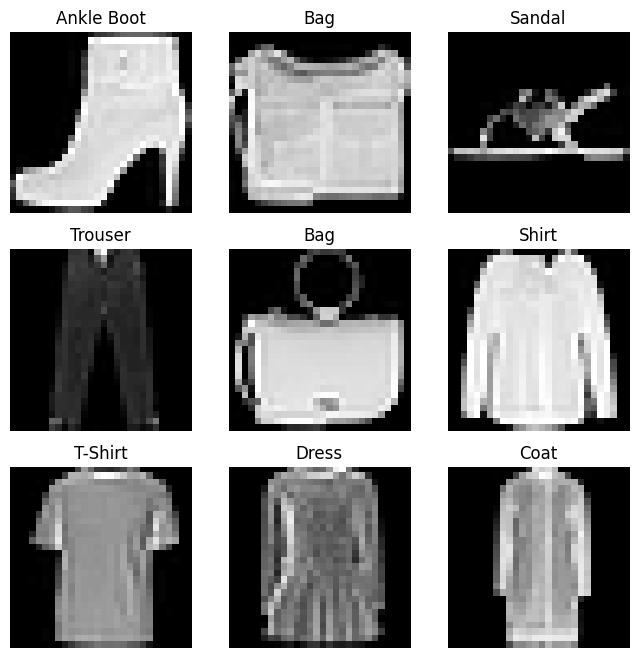

In [51]:
import torch
import torch.nn as nn
from torchvision.datasets import FashionMNIST, CIFAR10
# from torch.utils.data import Dataset
# from torchvision.transforms import ToTensor
import torch.optim as optim
import torch.utils.data as Data
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import matplotlib.pyplot as plt
from LeNet5 import LeNet5
from AlexNet import AlexNet


train_data = FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_data = FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

# 将数据集尺寸调整为227x227
# train_data = FashionMNIST(
#     root="./data",
#     train=True,
#     download=True,
#     transform=transforms.Compose([transforms.Resize(size=227), transforms.ToTensor()]),
# )

# test_data = FashionMNIST(
#     root="./data",
#     train=False,
#     download=True,
#     transform=transforms.Compose([transforms.Resize(size=227), transforms.ToTensor()]),
# )

# temp = torch.randint(len(train_data), size=(1,))
# print(train_data[temp.item()])

# 标签值
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))  # 画布大小
rows, cols = 3, 3
for i in range(1, rows * cols + 1):
    index = torch.randint(
        len(train_data), size=(1,)
    ).item()  # 随机在训练数据中取一个索引
    img, label = train_data[index]
    figure.add_subplot(rows, cols, i)  # 创建3 * 3 子图,i要 <= 3 * 3
    plt.title(labels_map[label])
    plt.axis("off")
    # print(img.shape) # (1, 28, 28)
    # print(img.squeeze().shape) # (28, 28)
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# 封装数据加载函数

In [58]:
# 加载FashionMNIST数据集
def load_data(dataset, batch_size: int, size=32):

    train_dataset = dataset(
        root="./data",
        train=True,
        download=True,
        transform=transforms.Compose([transforms.Resize(size=size), transforms.ToTensor()]),
    )
    test_dataset = dataset(
        root="./data",
        train=False,
        download=True,
        transform=transforms.Compose([transforms.Resize(size=size), transforms.ToTensor()]),
    )

    # 拆分出训练集和验证集
    train_data, valid_data = Data.random_split(
        train_dataset,
        [round(len(train_dataset) * 0.8), round(len(train_dataset) * 0.2)],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=True)
    # 测试集
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, valid_loader, test_loader


train_loader, valid_loader, test_loader = load_data(FashionMNIST, batch_size=64)

images, labels = next(iter(train_loader))

print(images.shape)  # 输入图像特征：[64, 1, 32, 32]
print(labels.shape)  # 输出真实标签：[64]

print(train_loader.__len__())  # 48000 / 64 = 750
print(train_loader.dataset.__len__())  # 48000
print(valid_loader.dataset.__len__())  # 12000
print(test_loader.dataset.__len__())  # 10000

torch.Size([64, 1, 32, 32])
torch.Size([64])
750
48000
12000
10000


# 定义训练、测试通用函数

In [53]:
# 训练模型
def train_model(
    model,
    train_loader,
    valid_loader,
    save_path: str,
    epochs=20,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"当前设备为：{device}")
    model = model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    valid_losses = []
    train_losses = []
    train_xAxis = []
    train_accs = []
    valid_accs = []
    for epoch in range(epochs):

        start_time = time.time()
        train_loss = 0  # 统计这一轮的所有批次的平均损失值之和
        correct_sum = 0  # 这一轮预测正确的个数
        for step, (images, labels) in enumerate(train_loader):
            model.train()
            # 将输入特征放入训练设备中
            images = images.to(device)
            # 将标签放入训练设备中
            labels = labels.to(device)
            # 前向传播
            output = model(images)
            # 计算损失值 (这一批次的平均损失)
            loss = criterion(output, labels)
            optimizer.zero_grad()
            # 反向传播
            loss.backward()
            # 更新参数
            optimizer.step()

            y_pred = torch.argmax(output, dim=1)
            correct_sum += (y_pred == labels).sum().item()
            train_loss += loss.item()

        train_xAxis.append(epoch)
        train_losses.append(train_loss / len(train_loader))
        train_acc = correct_sum / len(train_loader.dataset)
        train_accs.append(train_acc)

        print(
            f"第{epoch+1}轮训练的平均损失值为：{train_loss/len(train_loader):.4f}，准确率为：{train_acc:.4f}，耗时：{time.time()-start_time:.2f}秒"
        )

        # 验证集：验证集不参与模型参数的更新，只进行前向传播，验证模型的准确率
        start_time = time.time()
        correct_valid_sum = 0  # 这一轮验证集预测正确的个数
        valid_loss = 0  # 这一轮验证集的平均损失值之和
        for images, labels in valid_loader:
            model.eval()  # 设置为评估模式，不参与参数更新
            images = images.to(device)
            labels = labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            valid_loss += loss.item()
            y_pred = torch.argmax(output, dim=1)
            correct_valid_sum += (y_pred == labels).sum().item()
        valid_losses.append(valid_loss / len(valid_loader))
        valid_acc = correct_valid_sum / len(valid_loader.dataset)
        valid_accs.append(valid_acc)
        print(
            f"第{epoch+1}轮验证的平均损失值为：{valid_loss/len(valid_loader):.4f}，准确率为：{valid_acc:.4f}，耗时：{time.time()-start_time:.2f}秒"
        )

    torch.save(model.state_dict(), save_path)

    # 1.创建画布
    figure = plt.figure(figsize=(5, 5), dpi=100)
    # 绘制损失函数图像
    figure.add_subplot(2, 2, 1)
    plt.title("loss")
    plt.plot(train_xAxis, train_losses, label="train_loss", color="red")
    plt.plot(train_xAxis, valid_losses, label="valid_loss", color="blue")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    # 绘制准确率图像
    figure.add_subplot(2, 2, 2)
    plt.title("acc")
    plt.plot(train_xAxis, train_accs, label="train_acc", color="red")
    plt.plot(train_xAxis, valid_accs, label="valid_acc", color="blue")
    plt.xlabel("epoch")
    plt.ylabel("acc")
    plt.legend()
    plt.show()


# 测试模型
def test_model(model, model_path, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model().to(device)
    model.load_state_dict(torch.load(model_path))

    correct_sum = 0  # 测试集准确率
    for images, labels in test_loader:
        model.eval()
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        y_pred = torch.argmax(output, dim=1)
        correct_sum += (y_pred == labels).sum()

    print(f"测试集准确率为：{correct_sum / len(test_loader.dataset):.4f}")

# LeNet5模型训练

当前设备为：cuda
第1轮训练的平均损失值为：0.8555，准确率为：0.6599，耗时：9.05秒
第1轮验证的平均损失值为：0.5854，准确率为：0.7865，耗时：1.71秒
第2轮训练的平均损失值为：0.4860，准确率为：0.8174，耗时：9.54秒
第2轮验证的平均损失值为：0.4499，准确率为：0.8327，耗时：1.65秒
第3轮训练的平均损失值为：0.4291，准确率为：0.8416，耗时：9.40秒
第3轮验证的平均损失值为：0.4176，准确率为：0.8515，耗时：1.60秒
第4轮训练的平均损失值为：0.3947，准确率为：0.8565，耗时：9.69秒
第4轮验证的平均损失值为：0.3846，准确率为：0.8622，耗时：1.72秒
第5轮训练的平均损失值为：0.3679，准确率为：0.8662，耗时：10.00秒
第5轮验证的平均损失值为：0.3834，准确率为：0.8581，耗时：1.52秒
第6轮训练的平均损失值为：0.3520，准确率为：0.8722，耗时：9.41秒
第6轮验证的平均损失值为：0.3671，准确率为：0.8698，耗时：1.65秒
第7轮训练的平均损失值为：0.3423，准确率为：0.8761，耗时：9.12秒
第7轮验证的平均损失值为：0.3723，准确率为：0.8628，耗时：1.75秒
第8轮训练的平均损失值为：0.3284，准确率为：0.8796，耗时：9.54秒
第8轮验证的平均损失值为：0.3843，准确率为：0.8659，耗时：1.85秒
第9轮训练的平均损失值为：0.3212，准确率为：0.8844，耗时：9.49秒
第9轮验证的平均损失值为：0.3652，准确率为：0.8740，耗时：1.74秒
第10轮训练的平均损失值为：0.3157，准确率为：0.8859，耗时：9.68秒
第10轮验证的平均损失值为：0.3452，准确率为：0.8783，耗时：1.61秒


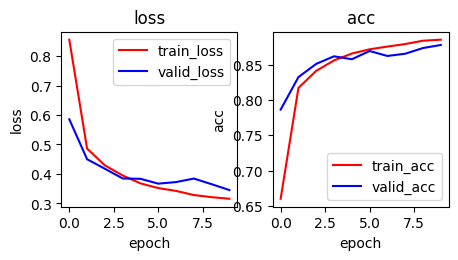

In [60]:
train_loader, valid_loader, test_loader = load_data(FashionMNIST, batch_size=16, size=32)
model = LeNet5
# 训练模型
train_model(
    model,
    train_loader,
    valid_loader,
    save_path="./model/LeNet5_model.pth",
    epochs=10,
)
# 测试模型
# test_model(model, "./model/LeNet5_model.pth", test_loader)

# AlexNet模型

In [62]:
train_loader, valid_loader, test_loader = load_data(CIFAR10, batch_size=32, size=227)
model = AlexNet

# 训练模型
train_model(
    model,
    train_loader,
    valid_loader,
    save_path="./model/AlexNet_model.pth",
    epochs=10,
)

当前设备为：cuda


KeyboardInterrupt: 

# VGGNet16模型训练

![image.png](./images/VGGNet.png)